### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

--- TOP 10 PAESI PER LITRI TOTALI DI ALCOL PURO ---
                country  total_litres_of_pure_alcohol
15              Belarus                          14.4
98            Lithuania                          12.9
3               Andorra                          12.4
68              Grenada                          11.9
61               France                          11.8
45       Czech Republic                          11.8
141  Russian Federation                          11.5
99           Luxembourg                          11.4
155            Slovakia                          11.4
81              Ireland                          11.4
------------------------------------------------------------
--- MEDIA CONSUMI ANNUALI (in porzioni/servings) ---
Media Birra:      106.16
Media Vino:       49.45
Media Distillati: 80.99
------------------------------------------------------------
Paese con il valore massimo di alcohol_index: Andorra (231.67)
-------------------------------------------

C:\Users\hp\AppData\Local\Temp\ipykernel_20124\2272389495.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


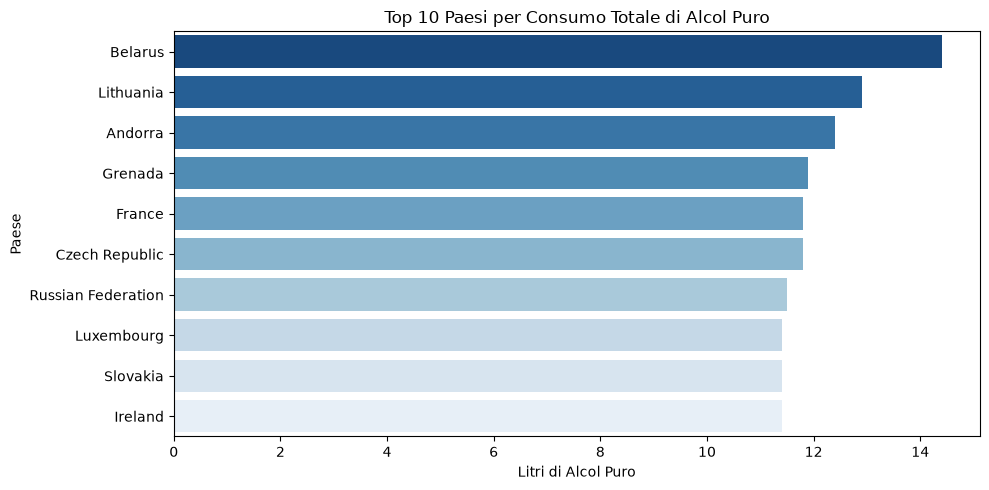

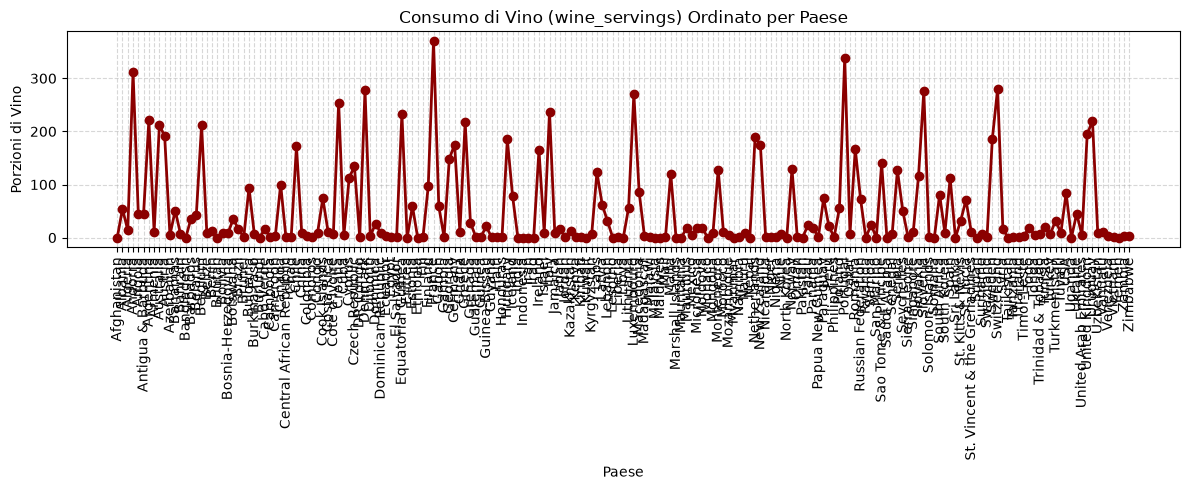

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df

import matplotlib.pyplot as plt
import seaborn as sns
# 1. Primi 10 paesi ordinati per total_litres_of_pure_alcohol 

top_10_alcohol = df.sort_values(by='total_litres_of_pure_alcohol', ascending=False).head(10)
print("--- TOP 10 PAESI PER LITRI TOTALI DI ALCOL PURO ---")
print(top_10_alcohol[['country', 'total_litres_of_pure_alcohol']])
print("-" * 60)

# ==============================================================================
# 2. Calcola la media del consumo di birra, vino e distillati
# ==============================================================================
media_birra = df['beer_servings'].mean()
media_vino = df['wine_servings'].mean()
media_distillati = df['spirit_servings'].mean()

print("--- MEDIA CONSUMI ANNUALI (in porzioni/servings) ---")
print(f"Media Birra:      {media_birra:.2f}")
print(f"Media Vino:       {media_vino:.2f}")
print(f"Media Distillati: {media_distillati:.2f}")
print("-" * 60)


# 3. Crea la nuova colonna alcohol_index

df['alcohol_index'] = (df['beer_servings'] + df['wine_servings'] + df['spirit_servings']) / 3


# 4. Trova il paese con il valore massimo di alcohol_index

# .idxmax() trova l'indice della riga associata al massimo; .loc estrae il valore
riga_max_index = df.loc[df['alcohol_index'].idxmax()]
print(f"Paese con il valore massimo di alcohol_index: {riga_max_index['country']} ({riga_max_index['alcohol_index']:.2f})")
print("-" * 60)


# 5. Filtra i paesi che consumano più di 100 birre all'anno

paesi_piu_100_birre = df[df['beer_servings'] > 100]
print(f"Numero di paesi con consumo di birra > 100: {len(paesi_piu_100_birre)}")
print("-" * 60)



# GRAFICO 1: Bar Chart dei 10 paesi con più consumo totale

plt.figure(figsize=(10, 5))
sns.barplot(
    x='total_litres_of_pure_alcohol', 
    y='country', 
    data=top_10_alcohol, 
    palette='Blues_r'
)
plt.title('Top 10 Paesi per Consumo Totale di Alcol Puro')
plt.xlabel('Litri di Alcol Puro')
plt.ylabel('Paese')
plt.tight_layout()
plt.show()



# GRAFICO 2: Line Plot con wine_servings ordinato per paese

plt.figure(figsize=(12, 5))

# Ordiniamo alfabeticamente per paese come richiesto dalla traccia
df_ordinato_paese = df.sort_values(by='country')

plt.plot(
    df_ordinato_paese['country'], 
    df_ordinato_paese['wine_servings'], 
    marker='o', 
    color='darkred', 
    linestyle='-', 
    linewidth=2
)
plt.title('Consumo di Vino (wine_servings) Ordinato per Paese')
plt.xlabel('Paese')
plt.ylabel('Porzioni di Vino')
plt.xticks(rotation=90)  # Evita la sovrapposizione dei nomi sull'asse X
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()





,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Caricamento del dataset
df = sns.load_dataset("tips")

# 2. Creazione della nuova colonna 'conto_per_persona'
df["conto_per_persona"] = df["total_bill"] / df["size"]

# 3. Analisi esplorativa: aggregazione per giorno ('day')
# Calcoliamo conto medio, conteggio osservazioni, minimo e massimo di 'total_bill'
analisi_giorni = (
    df.groupby("day")["total_bill"]
    .agg(conto_medio="mean", totale_osservazioni="count", min_conto="min", max_conto="max")
    .reset_index()
)

# Ordiniamo i dati dal conto medio più alto al più basso
analisi_giorni = analisi_giorni.sort_values(by="conto_medio", ascending=False)

# Mostra i risultati dell'analisi
print("--- Analisi delle Vendite Giornaliere ---")
print(analisi_giorni.to_string(index=False))

# 4. Trovare il giorno con il conto medio più alto
giorno_top = analisi_giorni.iloc[0]["day"]
valore_top = analisi_giorni.iloc[0]["conto_medio"]
print(f"\nIl giorno con il conto medio più alto è: {giorno_top} ({valore_top:.2f}$)")

# 5. Rappresentazione grafica (Grafico a barre)
plt.figure(figsize=(8, 5))
sns.barplot(
    x="day", y="conto_medio", data=analisi_giorni, palette="Blues_r", hue="day", legend=False
)

# Titolo ed etichette
plt.title("Conto Medio Giornaliero (Ordinato dal più alto al più basso)", fontsize=14, pad=15)
plt.xlabel("Giorno della Settimana", fontsize=12)
plt.ylabel("Conto Medio ($)", fontsize=12)

# Mostra il grafico
plt.tight_layout()
plt.show()